# Season-Specific Inference Demo

This notebook demonstrates the live inference path used by `inference.py`.

The demo does four things:

1. Finds the latest observation for each modeled target site/variable combo.
2. Inserts one hypothetical exact-hour observation using the same latest value. For example, if the latest row is `03:45` with value `70`, the demo inserts `04:00` with value `70`.
3. Lets the PostgreSQL hourly insert notification trigger inference, then stores the 24-hour predictions in `model_predictions`.
4. Plots recent history plus the new forecast, then deletes the hypothetical rows and their predictions.

Only season-specific models are used. No persistence baseline is computed or reported.

## 1. Setup

We import the project inference module instead of duplicating model-loading, feature-building, and prediction code. The notebook uses:

- `install_database_objects` to create the prediction table and hourly insert trigger.
- `discover_models` to load the season-specific model bundles.
- `event_from_notification` and `process_event` to handle the same trigger payload that the production listener handles.
- `build_hourly_series` to prepare recent history for plotting.

In [1]:
from __future__ import annotations

import os
import select
import sys
import time
from datetime import timedelta
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "inference.py").exists():
    candidate = PROJECT_ROOT / "CS6994FinalProject"
    if candidate.exists():
        PROJECT_ROOT = candidate

sys.path.insert(0, str(PROJECT_ROOT))

import inference

db_args = SimpleNamespace(
    db_host=os.environ.get("DB_HOST", "localhost"),
    db_port=int(os.environ.get("DB_PORT", "5433")),
    db_name=os.environ.get("DB_NAME", "database"),
    db_user=os.environ.get("DB_USER", "admin"),
    db_password=os.environ.get("DB_PASSWORD", "password"),
)

control_conn = inference.connect_db(db_args)
inference.install_database_objects(control_conn)

device = inference.choose_device("cpu")
models = inference.discover_models(PROJECT_ROOT, device=device, verbose=False)

runtime_args = SimpleNamespace(
    dry_run=False,
    no_csv=True,
    predictions_csv=str(PROJECT_ROOT / "demo_predictions.csv"),
    max_history_gap_hours=10,
)

print(f"Project root: {PROJECT_ROOT}")

Database inference tables and hourly insert trigger are installed.
Loaded 16 season-specific model bundle(s)
Project root: /uufs/chpc.utah.edu/common/home/u1591982/CS6994FinalProject


## 2. Find The Modeled Target Combos

The season-specific folders contain four seasons per modeled site. We collapse those models down to the unique target combinations that can trigger prediction:

- `air_temperature` at climate sites 1 and 2.
- `discharge` at stream sites 3 and 4.

In [2]:
combo_records = []
seen = set()

for model in models:
    key = (model.target_variable, model.site_id)
    if key in seen:
        continue
    seen.add(key)
    config = inference.TARGET_CONFIGS[model.target_variable]
    combo_records.append(
        {
            "target_variable": model.target_variable,
            "site_id": model.site_id,
            "variable_code": config.variable_code,
        }
    )

combo_records = sorted(combo_records, key=lambda row: (row["target_variable"], row["site_id"]))
combo_df = pd.DataFrame(combo_records)
combo_df

,target_variable,site_id,variable_code
0,air_temperature,1,AirTemp
1,air_temperature,2,AirTemp
2,discharge,3,Discharge
3,discharge,4,Discharge


## 3. Plan Hypothetical Exact-Hour Rows

For each modeled combo, we copy the latest observed value and move it to the next exact hourly timestamp.

Examples:

- Latest `03:45`, value `70` -> insert hypothetical `04:00`, value `70`.
- Latest `04:00`, value `70` -> insert hypothetical `05:00`, value `70`.

This makes the inserted timestamp both hourly and newer than the existing data, which is exactly what `inference.py` requires before it computes predictions.

In [3]:
def next_exact_hour(timestamp):
    ts = pd.Timestamp(timestamp)
    candidate = ts.ceil("h")
    if candidate <= ts:
        candidate = candidate + pd.Timedelta(hours=1)
    return candidate.to_pydatetime()


def fetch_latest_observation(conn, site_id: int, variable_code: str):
    sql = """
        SELECT
            d.datastream_id,
            d.datetime_utc,
            d.value,
            d.site_id,
            d.variable_id,
            d.owner_id,
            d.qualifier_id,
            d.processing_level_id,
            v.variable_code
        FROM datastream d
        JOIN variable v ON d.variable_id = v.variable_id
        WHERE d.site_id = %s
          AND v.variable_code = %s
        ORDER BY d.datetime_utc DESC, d.datastream_id DESC
        LIMIT 1
    """
    with conn.cursor(cursor_factory=inference.DictCursor) as cur:
        cur.execute(sql, (site_id, variable_code))
        row = cur.fetchone()
    if row is None:
        raise ValueError(f"No rows found for site_id={site_id}, variable_code={variable_code}")
    return dict(row)


latest_records = []
for combo in combo_records:
    latest = fetch_latest_observation(
        control_conn,
        site_id=combo["site_id"],
        variable_code=combo["variable_code"],
    )
    latest_records.append(
        {
            **combo,
            **latest,
            "latest_timestamp": latest["datetime_utc"],
            "latest_value": latest["value"],
            "hypothetical_timestamp": next_exact_hour(latest["datetime_utc"]),
            "hypothetical_value": latest["value"],
        }
    )

plan_df = pd.DataFrame(latest_records)[
    [
        "target_variable",
        "site_id",
        "variable_code",
        "latest_timestamp",
        "latest_value",
        "hypothetical_timestamp",
        "hypothetical_value",
    ]
]
plan_df

,target_variable,site_id,variable_code,latest_timestamp,latest_value,hypothetical_timestamp,hypothetical_value
0,air_temperature,1,AirTemp,2026-03-24 17:00:00,15.76,2026-03-24 18:00:00,15.76
1,air_temperature,2,AirTemp,2026-03-24 18:00:00,31.35,2026-03-24 19:00:00,31.35
2,discharge,3,Discharge,2026-03-24 06:00:00,214.20,2026-03-24 07:00:00,214.20
3,discharge,4,Discharge,2026-03-24 19:00:00,354.30,2026-03-24 20:00:00,354.30


## 4. Insert The Hypothetical Rows And Listen For Trigger Events

The database trigger created by `install_database_objects` sends a notification only for exact-hour inserts. The notebook starts a listener first, inserts all hypothetical rows, then drains the notification queue.

Each notification is converted back into a `DatastreamEvent` and passed to `process_event`, which builds the model input row, chooses the correct season-specific model, runs prediction, and writes rows to `model_predictions`.

In [4]:
listener_conn = inference.connect_db(db_args)
listener_conn.set_isolation_level(inference.psycopg2.extensions.ISOLATION_LEVEL_AUTOCOMMIT)
with listener_conn.cursor() as cur:
    cur.execute(f"LISTEN {inference.TARGET_CHANNEL};")

insert_sql = """
    INSERT INTO datastream (
        datetime_utc,
        value,
        site_id,
        variable_id,
        owner_id,
        qualifier_id,
        processing_level_id
    )
    VALUES (%s, %s, %s, %s, %s, %s, %s)
    RETURNING datastream_id, datetime_utc, value, site_id, variable_id
"""

inserted_rows = []
with control_conn.cursor(cursor_factory=inference.DictCursor) as cur:
    for record in latest_records:
        cur.execute(
            insert_sql,
            (
                record["hypothetical_timestamp"],
                record["hypothetical_value"],
                record["site_id"],
                record["variable_id"],
                record["owner_id"],
                record["qualifier_id"],
                record["processing_level_id"],
            ),
        )
        inserted = dict(cur.fetchone())
        inserted_rows.append({**record, **inserted})

control_conn.commit()
inserted_ids = [int(row["datastream_id"]) for row in inserted_rows]

pd.DataFrame(inserted_rows)[
    ["datastream_id", "target_variable", "site_id", "variable_code", "datetime_utc", "value"]
]

,datastream_id,target_variable,site_id,variable_code,datetime_utc,value
0,4067864,air_temperature,1,AirTemp,2026-03-24 18:00:00,15.76
1,4067865,air_temperature,2,AirTemp,2026-03-24 19:00:00,31.35
2,4067866,discharge,3,Discharge,2026-03-24 07:00:00,214.20
3,4067867,discharge,4,Discharge,2026-03-24 20:00:00,354.30


In [5]:
def drain_demo_notifications(listener, expected_ids: set[int], timeout_seconds: float = 10.0):
    events = []
    seen_ids = set()
    start = time.time()

    while time.time() - start < timeout_seconds and seen_ids != expected_ids:
        ready, _, _ = select.select([listener], [], [], 0.5)
        if not ready:
            continue

        listener.poll()
        while listener.notifies:
            notify = listener.notifies.pop(0)
            event = inference.event_from_notification(notify.payload)
            if event.datastream_id in expected_ids and event.datastream_id not in seen_ids:
                events.append(event)
                seen_ids.add(event.datastream_id)

    return events


events = drain_demo_notifications(listener_conn, set(inserted_ids))

# If a notebook kernel was busy and missed a notification, this fallback keeps the demo runnable.
# The production path should use the notification listener or the polling mode in inference.py.
missing_ids = sorted(set(inserted_ids) - {event.datastream_id for event in events})
for datastream_id in missing_ids:
    event = inference.fetch_event(control_conn, datastream_id)
    if event is not None:
        events.append(event)

print(f"Received or recovered {len(events)} event(s): {[event.datastream_id for event in events]}")

for event in sorted(events, key=lambda item: item.datastream_id):
    inference.process_event(control_conn, event, models, runtime_args)

Received or recovered 4 event(s): [4067864, 4067865, 4067866, 4067867]
Inference complete for datastream_id=4067864: 24 prediction row(s).
Inference complete for datastream_id=4067865: 24 prediction row(s).
Inference complete for datastream_id=4067866: 24 prediction row(s).
Inference complete for datastream_id=4067867: 24 prediction row(s).


## 5. Read The Predictions Stored In The Database

`process_event` stores the forecast in `model_predictions`. The table is long-format: one row per source insert, model, horizon, and target timestamp.

In [6]:
def fetch_demo_predictions(conn, source_ids: list[int]) -> pd.DataFrame:
    if not source_ids:
        return pd.DataFrame()

    sql = """
        SELECT
            source_datastream_id,
            target_variable,
            site_id,
            season,
            history_end_time,
            forecast_start_time,
            horizon,
            horizon_bin,
            target_timestamp,
            prediction,
            model_path
        FROM model_predictions
        WHERE source_datastream_id = ANY(%s)
        ORDER BY target_variable, site_id, horizon
    """
    with conn.cursor(cursor_factory=inference.DictCursor) as cur:
        cur.execute(sql, (source_ids,))
        rows = [dict(row) for row in cur.fetchall()]
    return pd.DataFrame(rows)


prediction_df = fetch_demo_predictions(control_conn, inserted_ids)
prediction_df.head(16)

,source_datastream_id,target_variable,site_id,season,history_end_time,forecast_start_time,horizon,horizon_bin,target_timestamp,prediction,model_path
0,4067864,air_temperature,1,spring,2026-03-24 18:00:00,2026-03-24 19:00:00,1,0-6,2026-03-24 19:00:00,16.649410,/uufs/chpc.utah.edu/common/home/u1591982/CS699...
1,4067864,air_temperature,1,spring,2026-03-24 18:00:00,2026-03-24 19:00:00,2,0-6,2026-03-24 20:00:00,17.158558,/uufs/chpc.utah.edu/common/home/u1591982/CS699...
2,4067864,air_temperature,1,spring,2026-03-24 18:00:00,2026-03-24 19:00:00,3,0-6,2026-03-24 21:00:00,17.141863,/uufs/chpc.utah.edu/common/home/u1591982/CS699...
3,4067864,air_temperature,1,spring,2026-03-24 18:00:00,2026-03-24 19:00:00,4,0-6,2026-03-24 22:00:00,16.701719,/uufs/chpc.utah.edu/common/home/u1591982/CS699...
4,4067864,air_temperature,1,spring,2026-03-24 18:00:00,2026-03-24 19:00:00,5,0-6,2026-03-24 23:00:00,16.284607,/uufs/chpc.utah.edu/common/home/u1591982/CS699...
5,4067864,air_temperature,1,spring,2026-03-24 18:00:00,2026-03-24 19:00:00,6,0-6,2026-03-25 00:00:00,14.902099,/uufs/chpc.utah.edu/common/home/u1591982/CS699...
6,4067864,air_temperature,1,spring,2026-03-24 18:00:00,2026-03-24 19:00:00,7,6-12,2026-03-25 01:00:00,13.011456,/uufs/chpc.utah.edu/common/home/u1591982/CS699...
7,4067864,air_temperature,1,spring,2026-03-24 18:00:00,2026-03-24 19:00:00,8,6-12,2026-03-25 02:00:00,10.861334,/uufs/chpc.utah.edu/common/home/u1591982/CS699...
8,4067864,air_temperature,1,spring,2026-03-24 18:00:00,2026-03-24 19:00:00,9,6-12,2026-03-25 03:00:00,9.441412,/uufs/chpc.utah.edu/common/home/u1591982/CS699...
9,4067864,air_temperature,1,spring,2026-03-24 18:00:00,2026-03-24 19:00:00,10,6-12,2026-03-25 04:00:00,7.574946,/uufs/chpc.utah.edu/common/home/u1591982/CS699...


## 6. Plot Recent History And The New Forecast

The history line is rebuilt with the same hourly-binning helper used by inference. The forecast line is the 24-hour prediction generated from the hypothetical exact-hour insert.

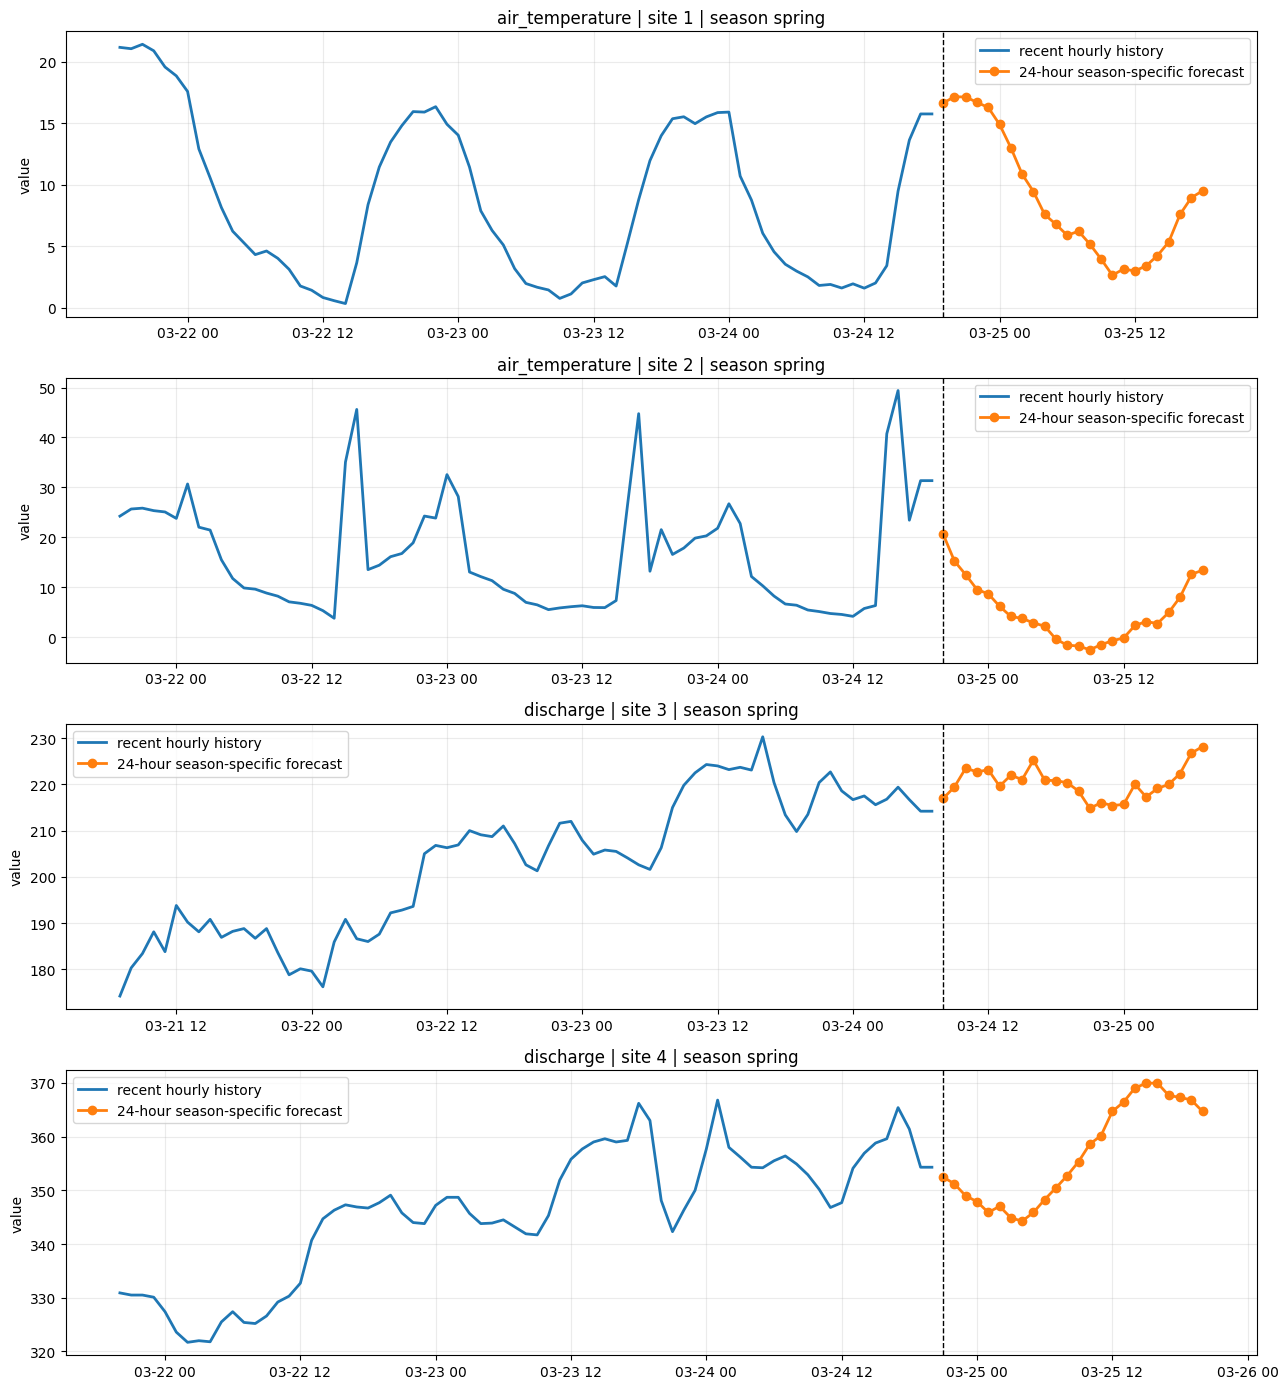

In [7]:
if prediction_df.empty:
    print("No predictions were generated. Check the event output above for skip messages.")
else:
    plot_df = prediction_df.copy()
    plot_df["history_end_time"] = pd.to_datetime(plot_df["history_end_time"])
    plot_df["forecast_start_time"] = pd.to_datetime(plot_df["forecast_start_time"])
    plot_df["target_timestamp"] = pd.to_datetime(plot_df["target_timestamp"])

    groups = list(plot_df.groupby(["target_variable", "site_id"], sort=True))
    fig, axes = plt.subplots(len(groups), 1, figsize=(13, 3.5 * len(groups)), sharex=False)
    if len(groups) == 1:
        axes = [axes]

    for ax, ((target_variable, site_id), group) in zip(axes, groups):
        config = inference.TARGET_CONFIGS[target_variable]
        history_end = group["history_end_time"].iloc[0].to_pydatetime()
        history_start = history_end - timedelta(hours=72)

        history = inference.build_hourly_series(
            control_conn,
            site_id=int(site_id),
            variable_code=config.variable_code,
            start_time=history_start,
            end_time=history_end,
            allow_negative=config.allow_negative,
            fill_mode="interpolate",
        )

        ax.plot(history["datetime"], history["value"], label="recent hourly history", linewidth=2)
        ax.plot(
            group["target_timestamp"],
            group["prediction"],
            label="24-hour season-specific forecast",
            marker="o",
            linewidth=2,
        )
        ax.axvline(group["forecast_start_time"].iloc[0], color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{target_variable} | site {site_id} | season {group['season'].iloc[0]}")
        ax.set_ylabel("value")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

## 7. Clean Up The Hypothetical Data

Run this cell after the demo. It deletes:

- The forecast rows generated from the hypothetical inserts.
- The hypothetical `datastream` rows themselves.

The database trigger and `model_predictions` table remain installed because those are the reusable inference infrastructure.

In [8]:
ids_to_delete = list(globals().get("inserted_ids", []))

if not ids_to_delete:
    print("No hypothetical datastream IDs found in this notebook session.")
else:
    with control_conn.cursor() as cur:
        cur.execute("DELETE FROM model_predictions WHERE source_datastream_id = ANY(%s)", (ids_to_delete,))
        deleted_predictions = cur.rowcount

        cur.execute("DELETE FROM datastream WHERE datastream_id = ANY(%s)", (ids_to_delete,))
        deleted_datastream_rows = cur.rowcount

    control_conn.commit()
    print(f"Deleted {deleted_predictions} prediction row(s).")
    print(f"Deleted {deleted_datastream_rows} hypothetical datastream row(s): {ids_to_delete}")

try:
    listener_conn.close()
except Exception:
    pass

try:
    control_conn.close()
except Exception:
    pass

Deleted 96 prediction row(s).
Deleted 4 hypothetical datastream row(s): [4067864, 4067865, 4067866, 4067867]
